Zadanie 10 – Batch vs Mini-batch vs Stochastic GD 

Porównaj trzy warianty Gradient Descent na tym samym zbiorze danych.
Dataset: `make_regression(n_samples=1000, n_features=1, noise=30)`

**6 punktów do zrealizowania:**

1. Zaimplementuj wszystkie 3 warianty  
2. Zmierz czas wykonania  
3. Porównaj krzywe uczenia  
4. Określ, który wariant jest najefektywniejszy  

**Oczekiwany rezultat:**

5. Tabela porównawcza (czas, końcowy loss, liczba iteracji)  
6. Wykres krzywych uczenia  

*Poniżej: jedna komórka kodu realizuje punkty 1–6 po kolei (opisy w `print` i na wykresie).*

Punkt 1 — zaimplementowano: batch_gradient_descent, mini_batch_gradient_descent, stochastic_gradient_descent

Punkt 2 — czas wykonania (cały trening do końca epok):
  Batch GD: 0.0020 s  (w=16.4041, b=0.1358)
  Mini-batch GD: 0.0166 s  (w=16.9066, b=2.5163)
  Stochastic GD: 0.0559 s  (w=17.2626, b=0.3924)

Punkt 5 — tabela: czas | końcowy loss (MSE) | liczba iteracji (aktualizacji wag)
  Ustalenia: epoki=100, n=1000, batch_size=32 → iter./epokę: 1 / 32 / 1000
Metoda             |   czas [s] |  MSE końcowe |  #iteracji
-----------------------------------------------------------
Batch GD           |     0.0020 |     882.1627 |        100
Mini-batch GD      |     0.0166 |     888.1177 |       3200
Stochastic GD      |     0.0559 |     882.9433 |     100000


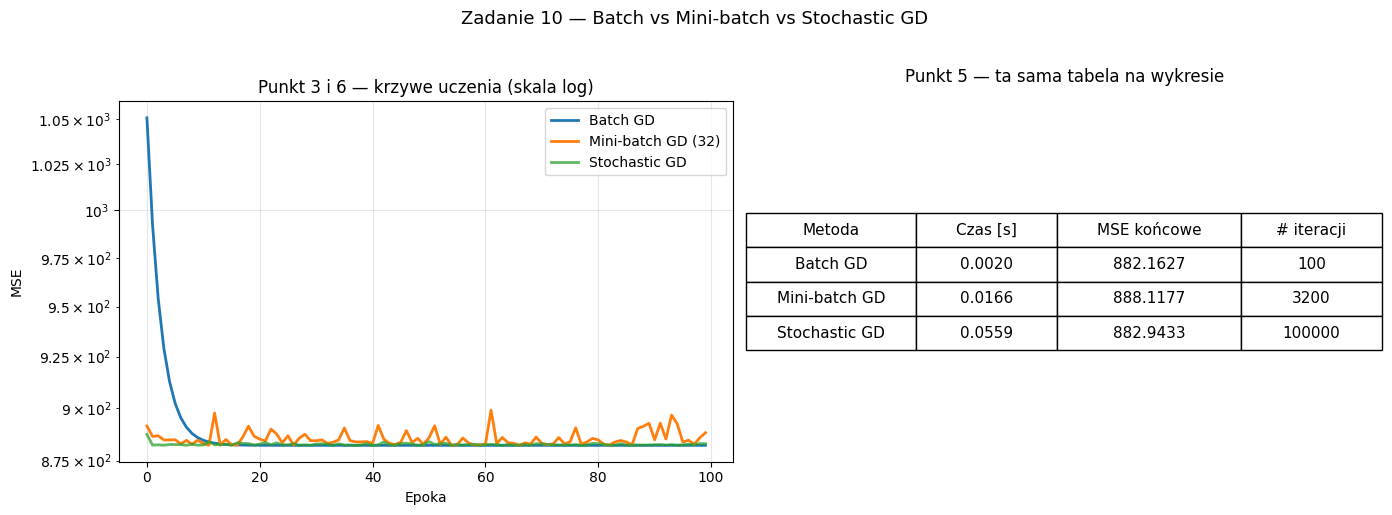


Punkt 3 — porównanie krzywych (po epokach):
  Spadek MSE (epoka 0 → ostatnia): Batch 168.51, Mini-batch 3.19, SGD 4.42
  Batch zwykle najgładszy; SGD bywa bardziej „poszarpany” przy małym batchu / 1 próbce.

Punkt 4 — który wariant najefektywniejszy? (zależy od kryterium)
  • Najniższy końcowy MSE (po 100 epokach): Batch GD → MSE = 882.1627
  • Najkrótszy czas treningu (te same epoki): Batch GD → 0.0020 s
  • Najniższy średni czas jednej aktualizacji wag (czas / #iteracji): Stochastic GD → 5.59e-07 s na aktualizację

  Wniosek ogólny: batch jest dokładny, ale kosztowny na dużych danych; 
 mini-batch to typowy kompromis w głębokim uczeniu; SGD — dużo aktualizacji, 
 szybsze epoki nie zawsze znaczą najlepszy MSE przy tych samych hiperparametrach.


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_regression

EPOCHS = 100
BATCH_SIZE = 32

# Dane: 
np.random.seed(42)
X, y = make_regression(n_samples=1000, n_features=1, noise=30, random_state=42)
X = X.flatten()
n = len(y)
n_batches_per_epoch = (n + BATCH_SIZE - 1) // BATCH_SIZE
N_UPD_BATCH = EPOCHS * 1
N_UPD_MINI = EPOCHS * n_batches_per_epoch
N_UPD_SGD = EPOCHS * n


# Punkt 1 — trzy warianty 


def predict(X, w, b):
    return w * X + b


def compute_gradients_batch(X, y, w, b):
    n_samples = len(y)
    y_pred = predict(X, w, b)
    error = y - y_pred
    dw = (-2 / n_samples) * np.sum(error * X)
    db = (-2 / n_samples) * np.sum(error)
    return dw, db


def batch_gradient_descent(X, y, lr=0.1, epochs=100):
    w, b = 0.0, 0.0
    losses = []
    for _ in range(epochs):
        dw, db = compute_gradients_batch(X, y, w, b)
        w -= lr * dw
        b -= lr * db
        losses.append(np.mean((y - predict(X, w, b)) ** 2))
    return w, b, losses


def stochastic_gradient_descent(X, y, lr=0.001, epochs=100):
    w, b = 0.0, 0.0
    losses = []
    n_samples = len(y)
    for _ in range(epochs):
        for i in np.random.permutation(n_samples):
            y_pred = predict(X[i], w, b)
            error = y[i] - y_pred
            dw = -2 * error * X[i]
            db = -2 * error
            w -= lr * dw
            b -= lr * db
        losses.append(np.mean((y - predict(X, w, b)) ** 2))
    return w, b, losses


def mini_batch_gradient_descent(X, y, lr=0.05, epochs=100, batch_size=32):
    w, b = 0.0, 0.0
    losses = []
    n_samples = len(y)
    for _ in range(epochs):
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i : i + batch_size]
            y_batch = y_shuffled[i : i + batch_size]
            y_pred = predict(X_batch, w, b)
            error = y_batch - y_pred
            m = len(X_batch)
            dw = (-2 / m) * np.sum(error * X_batch)
            db = (-2 / m) * np.sum(error)
            w -= lr * dw
            b -= lr * db
        losses.append(np.mean((y - predict(X, w, b)) ** 2))
    return w, b, losses


print("Punkt 1 — zaimplementowano: batch_gradient_descent, mini_batch_gradient_descent, stochastic_gradient_descent\n")

# Punkt 2 — pomiar czasu 

t0 = time.perf_counter()
w_bat, b_bat, loss_bat = batch_gradient_descent(X, y, lr=0.1, epochs=EPOCHS)
time_bat = time.perf_counter() - t0

t0 = time.perf_counter()
w_mini, b_mini, loss_mini = mini_batch_gradient_descent(
    X, y, lr=0.05, epochs=EPOCHS, batch_size=BATCH_SIZE
)
time_mini = time.perf_counter() - t0

t0 = time.perf_counter()
w_sgd, b_sgd, loss_sgd = stochastic_gradient_descent(X, y, lr=0.001, epochs=EPOCHS)
time_sgd = time.perf_counter() - t0

results = {
    "Batch GD": {
        "w": w_bat,
        "b": b_bat,
        "losses": loss_bat,
        "time": time_bat,
        "n_iter": N_UPD_BATCH,
    },
    "Mini-batch GD": {
        "w": w_mini,
        "b": b_mini,
        "losses": loss_mini,
        "time": time_mini,
        "n_iter": N_UPD_MINI,
    },
    "Stochastic GD": {
        "w": w_sgd,
        "b": b_sgd,
        "losses": loss_sgd,
        "time": time_sgd,
        "n_iter": N_UPD_SGD,
    },
}

print("Punkt 2 — czas wykonania (cały trening do końca epok):")
for name, r in results.items():
    print(f"  {name}: {r['time']:.4f} s  (w={r['w']:.4f}, b={r['b']:.4f})")

# Punkt 5 — tabela porównawcza 

print("\nPunkt 5 — tabela: czas | końcowy loss (MSE) | liczba iteracji (aktualizacji wag)")
print(f"  Ustalenia: epoki={EPOCHS}, n={n}, batch_size={BATCH_SIZE} → iter./epokę: 1 / {n_batches_per_epoch} / {n}")
hdr = f"{'Metoda':<18} | {'czas [s]':>10} | {'MSE końcowe':>12} | {'#iteracji':>10}"
print(hdr)
print("-" * len(hdr))
row_order = ["Batch GD", "Mini-batch GD", "Stochastic GD"]
for name in row_order:
    r = results[name]
    mse = r["losses"][-1]
    print(f"{name:<18} | {r['time']:10.4f} | {mse:12.4f} | {r['n_iter']:10d}")

# Punkt 3 i 6 — wykres krzywych uczenia + wizualizacja tabeli ==================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(loss_bat, label="Batch GD", linewidth=2)
axes[0].plot(loss_mini, label=f"Mini-batch GD ({BATCH_SIZE})", linewidth=2)
axes[0].plot(loss_sgd, label="Stochastic GD", linewidth=2, alpha=0.75)
axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("MSE")
axes[0].set_title("Punkt 3 i 6 — krzywe uczenia (skala log)")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].axis("off")
num_rows = [
    [name, f"{results[name]['time']:.4f}", f"{results[name]['losses'][-1]:.4f}", str(results[name]["n_iter"])]
    for name in row_order
]
tbl = axes[1].table(
    cellText=num_rows,
    colLabels=["Metoda", "Czas [s]", "MSE końcowe", "# iteracji"],
    cellLoc="center",
    loc="center",
    colWidths=[0.24, 0.2, 0.26, 0.2],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.15, 2.2)
axes[1].set_title("Punkt 5 — ta sama tabela na wykresie", pad=14)

plt.suptitle("Zadanie 10 — Batch vs Mini-batch vs Stochastic GD", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Punkt 3 — krótkie porównanie słowne (który spada szybciej / stabilniej)

final_mse = {name: results[name]["losses"][-1] for name in row_order}
drop_bat = results["Batch GD"]["losses"][0] - results["Batch GD"]["losses"][-1]
drop_mini = results["Mini-batch GD"]["losses"][0] - results["Mini-batch GD"]["losses"][-1]
drop_sgd = results["Stochastic GD"]["losses"][0] - results["Stochastic GD"]["losses"][-1]
print("\nPunkt 3 — porównanie krzywych (po epokach):")
print(f"  Spadek MSE (epoka 0 → ostatnia): Batch {drop_bat:.2f}, Mini-batch {drop_mini:.2f}, SGD {drop_sgd:.2f}")
print("  Batch zwykle najgładszy; SGD bywa bardziej „poszarpany” przy małym batchu / 1 próbce.")

# Punkt 4 — który najefektywniejszy? 

best_mse = min(final_mse, key=lambda k: final_mse[k])
best_time = min(results, key=lambda k: results[k]["time"])
avg_upd = {k: results[k]["time"] / results[k]["n_iter"] for k in row_order}
best_avg = min(avg_upd, key=lambda k: avg_upd[k])

print("\nPunkt 4 — który wariant najefektywniejszy? (zależy od kryterium)")
print(f"  • Najniższy końcowy MSE (po {EPOCHS} epokach): {best_mse} → MSE = {final_mse[best_mse]:.4f}")
print(f"  • Najkrótszy czas treningu (te same epoki): {best_time} → {results[best_time]['time']:.4f} s")
print(
    f"  • Najniższy średni czas jednej aktualizacji wag (czas / #iteracji): {best_avg} "
    f"→ {avg_upd[best_avg]:.2e} s na aktualizację"
)
print(
    "\n  Wniosek ogólny: batch jest dokładny, ale kosztowny na dużych danych; "
    "\n mini-batch to typowy kompromis w głębokim uczeniu; SGD — dużo aktualizacji, "
    "\n szybsze epoki nie zawsze znaczą najlepszy MSE przy tych samych hiperparametrach."
)


Zadanie 12 – Learning Curves Analysis
Przeanalizuj learning curves dla modelu.

Dataset: California Housing

Wymagania:
- Wygeneruj learning curves dla SGDRegressor
- Zidentyfikuj, czy model ma underfitting/overfitting
- Zaproponuj rozwiązanie

Oczekiwany rezultat:
- Wykres learning curves
- Diagnoza i rekomendacje

/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

=== Learning Curves Analysis ===
Rozmiary treningowe: [ 1651  3302  4953  6604  8256  9907 11558 13209 14860 16512]

Train MSE (final): 0.5243
Val MSE (final): 0.5579
Gap: 0.0336

Diagnoza: ✓ Model dobrze uogólnia (mały gap)


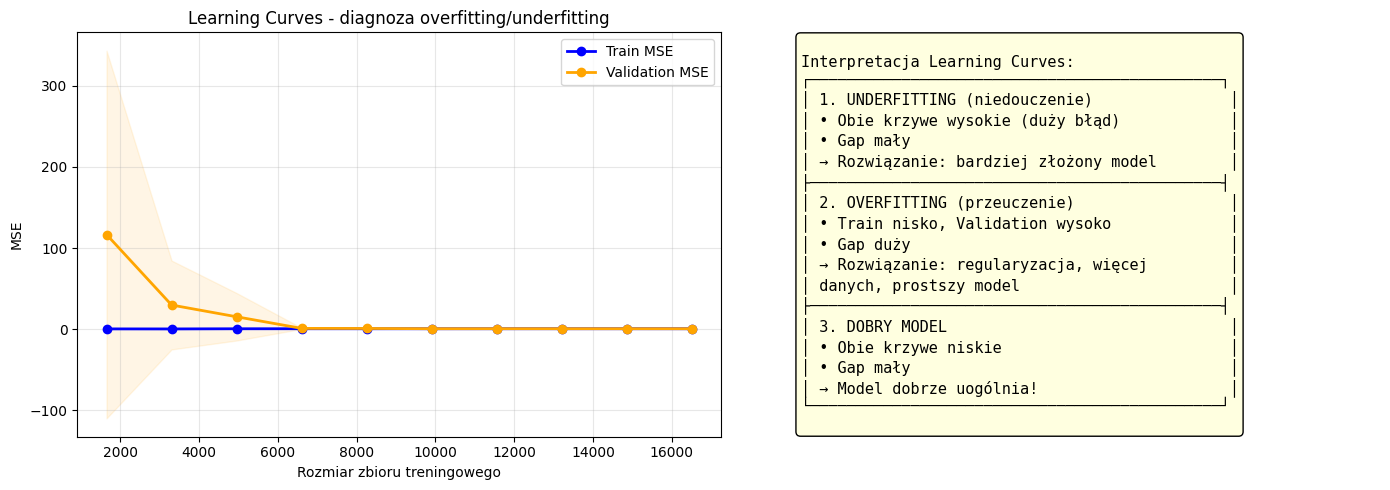

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import Pipeline

# 1. Wczytywanie danych 
housing = fetch_california_housing()
X, y = housing.data, housing.target

# 2. Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SGDRegressor(learning_rate='constant', eta0=0.0001, max_iter=1000, random_state=42))
])

# 3. Learning curves
train_sizes, train_scores, val_scores = learning_curve(
    pipeline, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# 4. Konwersja na MSE i obliczenie średnich
train_mse = -train_scores.mean(axis=1)
val_mse = -val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

print("=== Learning Curves Analysis ===")
print(f"Rozmiary treningowe: {train_sizes}")
print(f"\nTrain MSE (final): {train_mse[-1]:.4f}")
print(f"Val MSE (final): {val_mse[-1]:.4f}")
print(f"Gap: {val_mse[-1] - train_mse[-1]:.4f}") 

# 5. Interpretacja
gap = val_mse[-1] - train_mse[-1]
if gap < 0.1:
    diagnosis = "✓ Model dobrze uogólnia (mały gap)"
elif gap < 0.5:
    diagnosis = "⚠ Lekki overfitting (średni gap)"
else:
    diagnosis = "✗ Silny overfitting (duży gap)"
print(f"\nDiagnoza: {diagnosis}")

# 6. Wizualizacja
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Learning curves:
axes[0].fill_between(train_sizes, train_mse - train_std, train_mse +
train_std, alpha=0.1, color='blue')
axes[0].fill_between(train_sizes, val_mse - val_std, val_mse + val_std,
alpha=0.1, color='orange')
axes[0].plot(train_sizes, train_mse, 'o-', label='Train MSE', color='blue',
linewidth=2)
axes[0].plot(train_sizes, val_mse, 'o-', label='Validation MSE',
color='orange', linewidth=2)
axes[0].set_xlabel('Rozmiar zbioru treningowego')
axes[0].set_ylabel('MSE')
axes[0].set_title('Learning Curves - diagnoza overfitting/underfitting')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# 2. Schemat interpretacji
axes[1].axis('off')
interpretations = """
Interpretacja Learning Curves:
┌─────────────────────────────────────────────┐
│ 1. UNDERFITTING (niedouczenie)               │
│ • Obie krzywe wysokie (duży błąd)            │
│ • Gap mały                                   │
│ → Rozwiązanie: bardziej złożony model        │
├─────────────────────────────────────────────┤
│ 2. OVERFITTING (przeuczenie)                 │
│ • Train nisko, Validation wysoko             │
│ • Gap duży                                   │
│ → Rozwiązanie: regularyzacja, więcej         │
│ danych, prostszy model                       │
├─────────────────────────────────────────────┤
│ 3. DOBRY MODEL                               │
│ • Obie krzywe niskie                         │
│ • Gap mały                                   │
│ → Model dobrze uogólnia!                     │
└─────────────────────────────────────────────┘
"""
axes[1].text(0.1, 0.5, interpretations, fontsize=11, 
verticalalignment='center', fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow'))
plt.tight_layout()
plt.show()